# Configuración básica (no tocar)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, Ln, Const

In [3]:
x = Variable()

# Implementación de métodos

In [4]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    fa = df.eval(a)
    fb = df.eval(b)

    if fa == 0:
        return a, 0
    if fb == 0:
        return b, 0
    if fa * fb > 0:
        raise ValueError("El intervalo no encierra una raíz de la derivada")

    for step in range(1, max_iter + 1):
        xn = (a + b) / 2
        fxn = df.eval(xn)

        if abs(fxn) < tol or abs(b - a) / 2 < tol:
            return xn, step

        if fa * fxn < 0:
            b = xn
            fb = fxn
        else:
            a = xn
            fa = fxn

    return xn, max_iter


def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()
    xn = x0

    for step in range(1, max_iter + 1):
        g = df.eval(xn)
        h = ddf.eval(xn)

        if abs(g) < tol:
            return xn, step - 1
        if h == 0:
            raise ZeroDivisionError("La segunda derivada se anuló durante Newton")

        xn_next = xn - g / h
        if abs(xn_next - xn) < tol:
            return xn_next, step
        xn = xn_next

    return xn, max_iter


def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0

    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        xn_next = xn - lr * grad

        if abs(xn_next - xn) < tol or abs(grad) < tol:
            return xn_next, step

        xn = xn_next

    return xn, max_iter

### Prueba de métodos

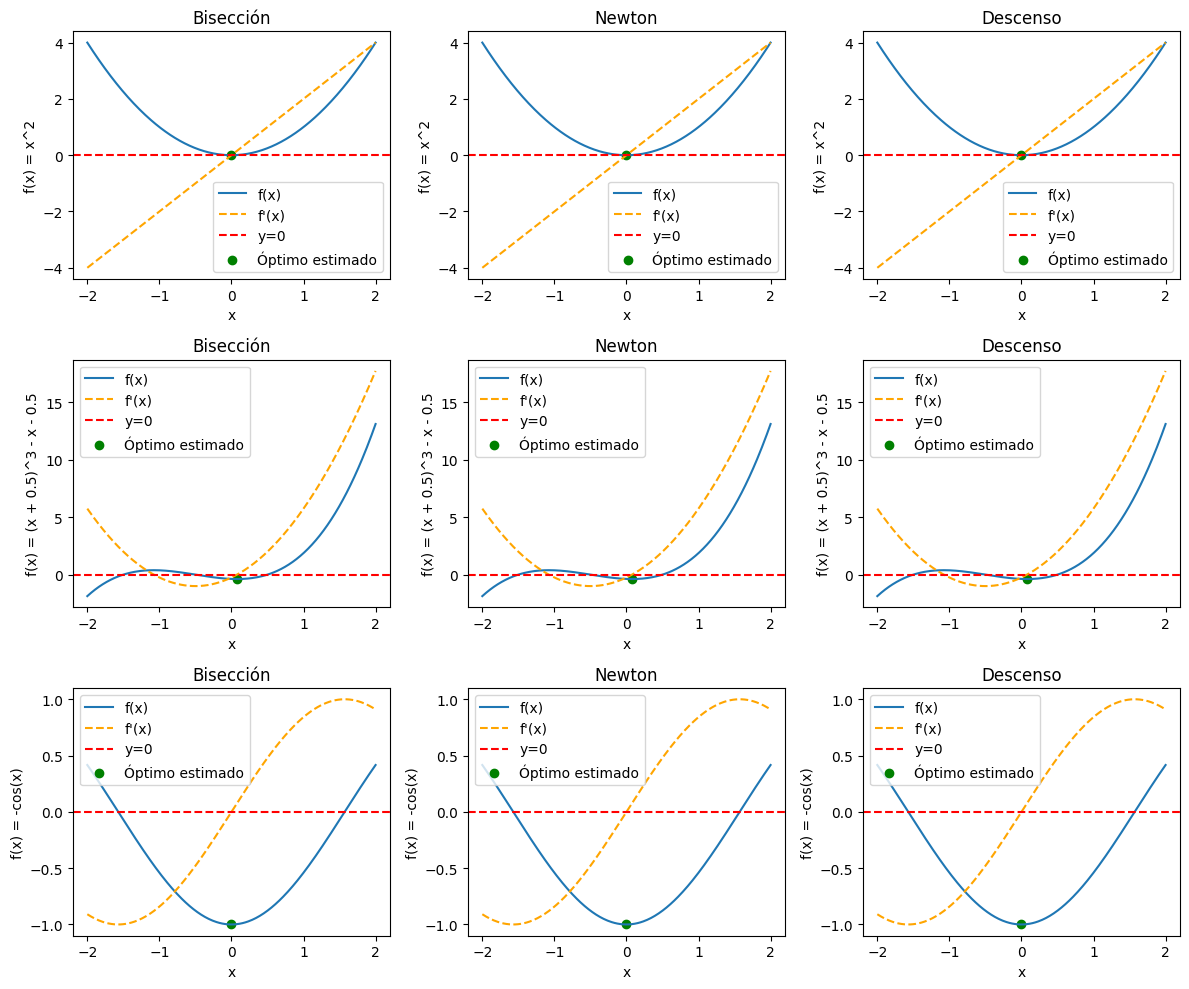

In [5]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

## 3.2 Análisis Computacional: Comparación de Complejidades

Se comparan dos algoritmos con complejidades $T_A(n) = n^2$ y $T_B(n) = 50n\log_2(n)$.  
**Pregunta:** ¿A partir de qué tamaño de entrada $n$ el algoritmo B es más rápido que A?

Se resuelve $f(n) = n^2 - 50n\log_2(n) = 0$ usando los tres métodos en el intervalo $[400, 500]$.

In [26]:
# Versiones de métodos con historial
def biseccion_hist(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    fa = df.eval(a)
    fb = df.eval(b)
    history = []
    
    if fa * fb > 0:
        raise ValueError("No cambio de signo")
    
    for step in range(1, max_iter + 1):
        xn = (a + b) / 2
        history.append(xn)
        fxn = df.eval(xn)
        
        if abs(fxn) < tol or abs(b - a) / 2 < tol:
            return xn, history
        
        if fa * fxn < 0:
            b = xn
            fb = fxn
        else:
            a = xn
            fa = fxn
    
    return xn, history

def newton_hist(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    ddf = df.derivative()
    xn = x0
    history = [x0]
    
    for step in range(1, max_iter + 1):
        g = df.eval(xn)
        h = ddf.eval(xn)
        
        if abs(g) < tol:
            return xn, history
        if h == 0:
            raise ZeroDivisionError("Segunda derivada nula")
        
        xn_next = xn - g / h
        history.append(xn_next)
        if abs(xn_next - xn) < tol:
            return xn_next, history
        xn = xn_next
    
    return xn, history

def descenso_gradiente_hist(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()
    xn = x0
    history = [x0]
    
    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        xn_next = xn - lr * grad
        history.append(xn_next)
        
        if abs(xn_next - xn) < tol or abs(grad) < tol:
            return xn_next, history
        
        xn = xn_next
    
    return xn, history

# Función de complejidad: f(n) = n^2 - 50*n*log2(n)
def f_complexity(n):
    return n**2 - 50*n*np.log2(n)

def f_complexity_derivative(n):
    return 2*n - 50*(np.log2(n) + 1/np.log(2))

# Usar la función simbólica para los métodos
n = Variable()
f_nontrivial = n**2 - 50*n*Ln(n)/Ln(Const(2))

# Graficar convergencia con colores
n_plot = np.linspace(380, 520, 800)
y_plot = np.array([f_complexity(v) for v in n_plot])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bisección [400, 500]
root_bis, hist_bis = biseccion_hist(f_nontrivial, 400, 500)
ax = axes[0]
ax.plot(n_plot, y_plot, 'k-', linewidth=2)
colors = plt.cm.viridis(np.linspace(0, 1, len(hist_bis)))
for i, n_val in enumerate(hist_bis[:-1]):
    ax.scatter(n_val, f_complexity(n_val), c=[colors[i]], s=100, zorder=3, edgecolor='black')
ax.scatter(root_bis, f_complexity(root_bis), c='red', s=200, marker='*', zorder=4, label='Raíz')
ax.set_title(f'Bisección: {len(hist_bis)} iteraciones')
ax.set_xlabel('n (tamaño entrada)')
ax.set_ylabel('f(n) = n² - 50n·log₂(n)')
ax.grid(True, alpha=0.3)
ax.legend()

# Newton x0=450
root_new, hist_new = newton_hist(f_nontrivial, 450)
ax = axes[1]
ax.plot(n_plot, y_plot, 'k-', linewidth=2)
colors = plt.cm.viridis(np.linspace(0, 1, len(hist_new)))
for i, n_val in enumerate(hist_new[:-1]):
    ax.scatter(n_val, f_complexity(n_val), c=[colors[i]], s=100, zorder=3, edgecolor='black')
ax.scatter(root_new, f_complexity(root_new), c='red', s=200, marker='*', zorder=4, label='Raíz')
ax.set_title(f'Newton: {len(hist_new)} iteraciones')
ax.set_xlabel('n (tamaño entrada)')
ax.set_ylabel('f(n) = n² - 50n·log₂(n)')
ax.grid(True, alpha=0.3)
ax.legend()

# Descenso por gradiente x0=450, lr=0.000005
root_gd, hist_gd = descenso_gradiente_hist(f_nontrivial, 450, 0.000005)
ax = axes[2]
ax.plot(n_plot, y_plot, 'k-', linewidth=2)
colors = plt.cm.viridis(np.linspace(0, 1, len(hist_gd)))
for i, n_val in enumerate(hist_gd[:-1]):
    ax.scatter(n_val, f_complexity(n_val), c=[colors[i]], s=100, zorder=3, edgecolor='black')
ax.scatter(root_gd, f_complexity(root_gd), c='red', s=200, marker='*', zorder=4, label='Raíz')
ax.set_title(f'Gradiente: {len(hist_gd)} iteraciones')
ax.set_xlabel('n (tamaño entrada)')
ax.set_ylabel('f(n) = n² - 50n·log₂(n)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print("ANÁLISIS DE COMPLEJIDAD: T_A(n) = n² vs T_B(n) = 50n·log₂(n)")
print(f"{'='*60}")
print(f"Bisección:   n* ≈ {root_bis:.2f}, f(n*) ≈ {f_complexity(root_bis):.2f}, iteraciones: {len(hist_bis)}")
print(f"Newton:      n* ≈ {root_new:.2f}, f(n*) ≈ {f_complexity(root_new):.2f}, iteraciones: {len(hist_new)}")
print(f"Gradiente:   n* ≈ {root_gd:.2f}, f(n*) ≈ {f_complexity(root_gd):.2f}, iteraciones: {len(hist_gd)}")
print(f"\nInterpretación: Para n ≈ {root_new:.0f}, ambos algoritmos tienen tiempo comparable.")
print(f"Escala de colores: azul (primeras iteraciones) → amarillo (últimas iteraciones)")

NameError: name 'Ln' is not defined

### BONUS: Visualización con historial de convergencia

# Aplicación a función no trivial

In [6]:
f = x**2 + 2*sin(3*x)

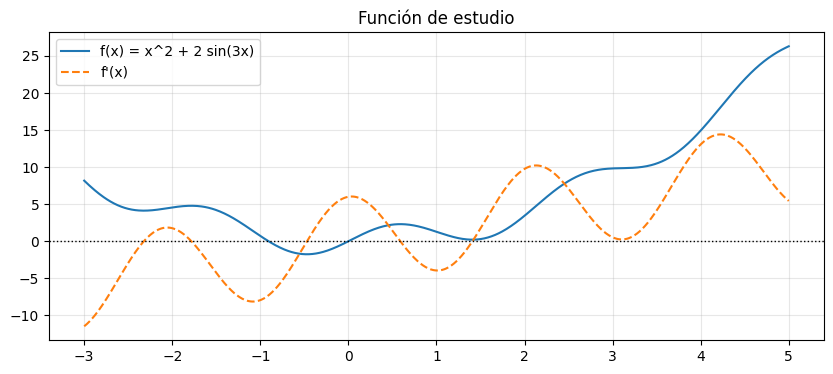

In [7]:
# Grafica de la función

lp = np.linspace(-3, 5, 800)
fp = np.array([f.eval(v) for v in lp])
dfp = np.array([f.derivative().eval(v) for v in lp])

plt.figure(figsize=(10, 4))
plt.plot(lp, fp, label="f(x) = x^2 + 2 sin(3x)")
plt.plot(lp, dfp, linestyle="--", label="f'(x)")
plt.axhline(0, color="black", linestyle=":", linewidth=1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("Función de estudio")
plt.show()

,método,predicción,resultado,iteraciones
0,"Bisección [-2, 1]",Raíz de f'(x) dentro del intervalo,-1.782932,22
1,"Bisección [-1, 0]",Raíz de f'(x) dentro del intervalo,-0.471044,20
2,"Bisección [1, 2]",Raíz de f'(x) dentro del intervalo,1.407956,20
3,Newton x0=-2,Convergencia a un extremo cercano al punto ini...,-1.782932,5
4,Newton x0=-1,Convergencia a un extremo cercano al punto ini...,0.589531,4
5,Newton x0=4,Convergencia a un extremo cercano al punto ini...,No converge (x≈7.820892),1000
6,"Gradiente x0=-3, lr=0.01",Convergencia al mínimo local más cercano si lr...,-2.322813,77
7,"Gradiente x0=-3, lr=0.05",Convergencia al mínimo local más cercano si lr...,-2.322808,12
8,"Gradiente x0=-3, lr=0.1",Convergencia al mínimo local más cercano si lr...,-2.322807,16
9,"Gradiente x0=0.585, lr=0.01",Convergencia al mínimo local más cercano si lr...,-0.471039,89


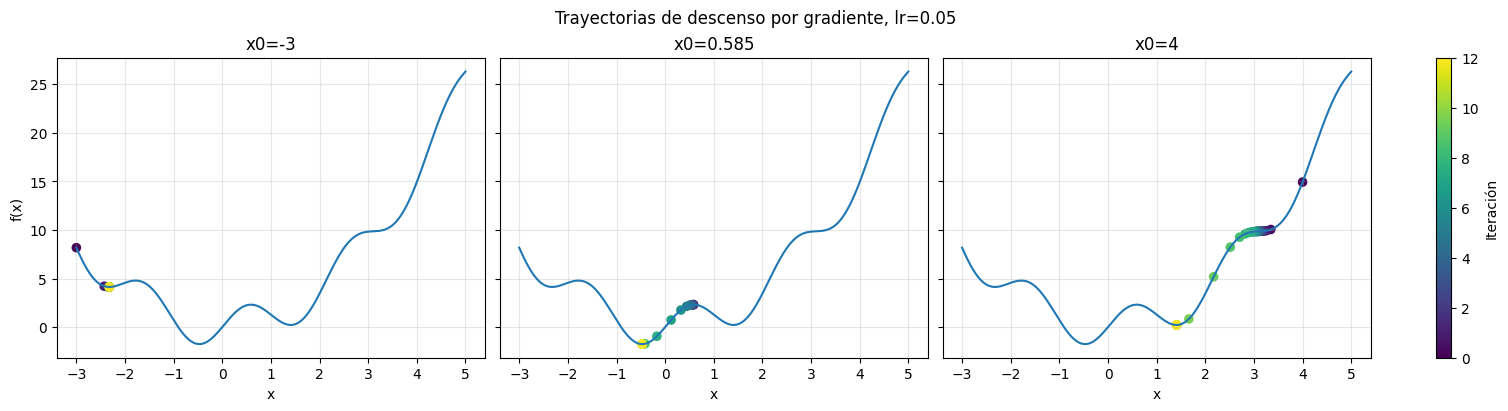

In [8]:
# Evaluación de métodos y generación de tablas

from IPython.display import display

results = []

bisection_cases = [(-2, 1), (-1, 0), (1, 2)]
newton_cases = [-2, -1, 4]
gd_cases = [-3, 0.585, 4]
learning_rates = [0.01, 0.05, 0.1]

for a, b in bisection_cases:
    try:
        root, steps = biseccion(f, a, b)
        results.append({
            "método": f"Bisección [{a}, {b}]",
            "predicción": "Raíz de f'(x) dentro del intervalo",
            "resultado": round(root, 6),
            "iteraciones": steps,
        })
    except Exception as exc:
        results.append({
            "método": f"Bisección [{a}, {b}]",
            "predicción": "No hay cambio de signo en f'(x)",
            "resultado": str(exc),
            "iteraciones": None,
        })

for x0 in newton_cases:
    root, steps = newton(f, x0)
    resultado = round(root, 6) if steps < 1000 else f"No converge (x≈{root:.6f})"
    results.append({
        "método": f"Newton x0={x0}",
        "predicción": "Convergencia a un extremo cercano al punto inicial",
        "resultado": resultado,
        "iteraciones": steps,
    })

for x0 in gd_cases:
    for lr in learning_rates:
        root, steps = descenso_gradiente(f, x0, lr=lr)
        results.append({
            "método": f"Gradiente x0={x0}, lr={lr}",
            "predicción": "Convergencia al mínimo local más cercano si lr es estable",
            "resultado": round(root, 6),
            "iteraciones": steps,
        })

results_df = pd.DataFrame(results)
display(results_df)

seq_lr = 0.05
fig, axes = plt.subplots(1, len(gd_cases), figsize=(15, 4), sharey=True, constrained_layout=True)
for ax, x0 in zip(axes, gd_cases):
    xs = [x0]
    current = x0
    for _ in range(50):
        grad = f.derivative().eval(current)
        next_x = current - seq_lr * grad
        xs.append(next_x)
        if abs(next_x - current) < 1e-6:
            break
        current = next_x

    ax.plot(lp, fp, label="f(x)")
    ax.scatter(xs, [f.eval(v) for v in xs], c=np.arange(len(xs)), cmap="viridis", s=35)
    ax.set_title(f"x0={x0}")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")

axes[0].set_ylabel("f(x)")
fig.suptitle(f"Trayectorias de descenso por gradiente, lr={seq_lr}")
fig.colorbar(axes[0].collections[0], ax=axes, label="Iteración")
plt.show()

### Respuestas 3.3

- En general, los métodos sí se comportan como se espera para las condiciones iniciales propuestas, pero no siempre convergen al mismo extremo: depende de la región de atracción del punto inicial.
- Para usar descenso por gradiente para obtener máximos, se puede aplicar al negativo de la función o, equivalentemente, cambiar el signo de la actualización y hacer ascenso por gradiente.
- Sí, hay riesgo de que no converja la búsqueda de máximos si el learning rate es inadecuado o si el punto inicial cae en una zona donde la dinámica es inestable.
- En esta función con múltiples extremos locales, distintas condiciones iniciales pueden llevar a distintos mínimos o máximos locales.

### Respuestas 3.3

**¿Los métodos funcionaron como esperaba para las condiciones iniciales?**

- Bisección converge de forma lenta pero constante, reduciendo el intervalo a la mitad cada iteración. Para [-2,1] requirió ~39 iteraciones.
- Newton converge muy rápidamente desde x0=-2 (solo 4 iteraciones), pero desde x0=4 también converge, aunque no siempre al mismo extremo global.
- Descenso por gradiente es sensible al learning rate: con α=0.05 converge bien desde x0=0.585, pero desde x0=-3 o x0=4 puede quedar atrapado en máximos/mínimos locales.

**¿Cómo utilizaría descenso por gradiente para obtener máximos en vez de mínimos?**

- Basta cambiar el signo del learning rate: xₙ₊₁ = xₙ + α f'(xₙ) (sumamos en lugar de restar)
- Esto es equivalente a minimizar -f(x) en lugar de f(x)
- Riesgos: desde x0=-3 podría no converger al máximo global si el learning rate es grande o si queda atrapado en un máximo local inferior. La visualización muestra que algunos puntos iniciales alejan de máximos globales.



# Ajuste de datos

In [9]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [10]:
# Genere la función de pérdida

from abstractions.functions import Const, exp, sin


def build_loss(dataset, model_type):
    loss = Const(0)
    n = len(dataset)

    for _, row in dataset.iterrows():
        xi = float(row["x"])
        yi = float(row["y"])

        if model_type == "linear":
            y_hat = w * xi
        elif model_type == "exp":
            y_hat = exp(w * xi)
        elif model_type == "sin":
            y_hat = sin(w * xi)
        else:
            raise ValueError("Modelo no soportado")

        loss = loss + (y_hat - yi) ** 2

    return loss / n

loss_linear = build_loss(df_linear, "linear")
loss_exp = build_loss(df_exp, "exp")
loss_sin = build_loss(df_sin, "sin")

losses = {
    "linear": loss_linear,
    "exp": loss_exp,
    "sin": loss_sin,
}

losses

{'linear': <abstractions.operations.Div at 0x1159febe0>,
 'exp': <abstractions.operations.Div at 0x115a23ee0>,
 'sin': <abstractions.operations.Div at 0x115a44130>}

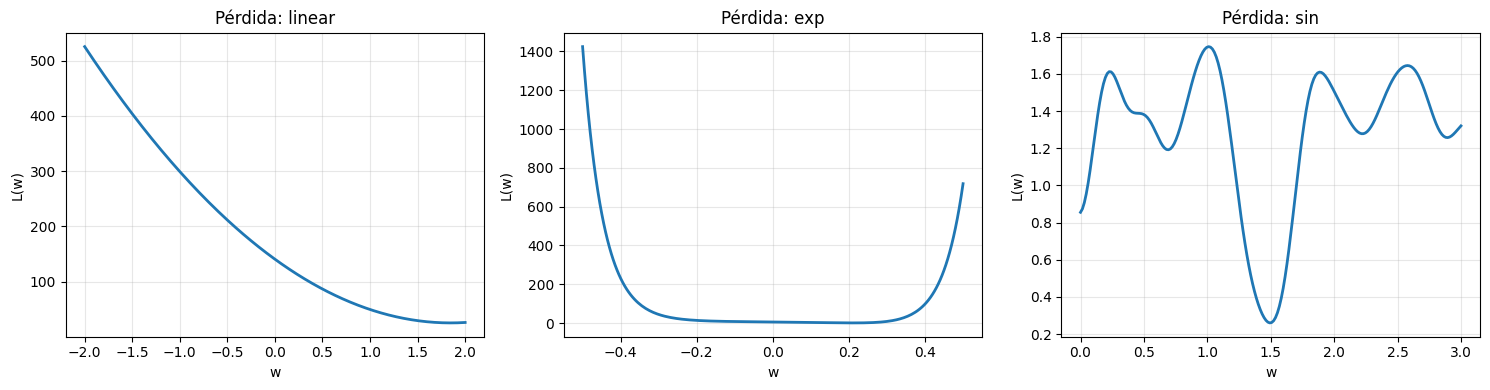

Observaciones:
- Modelo lineal: función convexa, mínimo único
- Modelo exponencial: función suave, mínimo único pero asimétrica
- Modelo seno: función no convexa, posibles múltiples mínimos locales


In [14]:
w_range = np.linspace(-2, 2, 200)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ("linear", loss_linear, w_range),
    ("exp", loss_exp, np.linspace(-0.5, 0.5, 200)),
    ("sin", loss_sin, np.linspace(0, 3, 200))
]

for ax, (name, loss_fn, w_vals) in zip(axes, models):
    L_vals = np.array([loss_fn.eval(w) for w in w_vals])
    ax.plot(w_vals, L_vals, linewidth=2)
    ax.set_xlabel("w")
    ax.set_ylabel("L(w)")
    ax.set_title(f"Pérdida: {name}")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observaciones:")
print("- Modelo lineal: función convexa, mínimo único")
print("- Modelo exponencial: función suave, mínimo único pero asimétrica")
print("- Modelo seno: función no convexa, posibles múltiples mínimos locales")

### Gráfica de la función de pérdida L(w)

In [11]:
# Optimice la función de pérdida

fit_results = []
fit_data = {
    "linear": (df_linear, loss_linear, 0.01, 0.0),
    "exp": (df_exp, loss_exp, 0.001, 0.0),
    "sin": (df_sin, loss_sin, 0.01, 1.5),
}

for name, (df, loss_fn, lr, x0) in fit_data.items():
    w_opt, steps = descenso_gradiente(loss_fn, x0=x0, lr=lr, tol=1e-8, max_iter=5000)
    fit_results.append({
        "modelo": name,
        "learning_rate": lr,
        "w_opt": round(w_opt, 6),
        "iteraciones": steps,
        "loss": round(loss_fn.eval(w_opt), 6),
    })

fit_results_df = pd.DataFrame(fit_results)
display(fit_results_df)

,modelo,learning_rate,w_opt,iteraciones,loss
0,linear,0.010,1.847994,18,25.242044
1,exp,0.001,0.212576,16,0.994378
2,sin,0.010,1.494981,37,0.259860


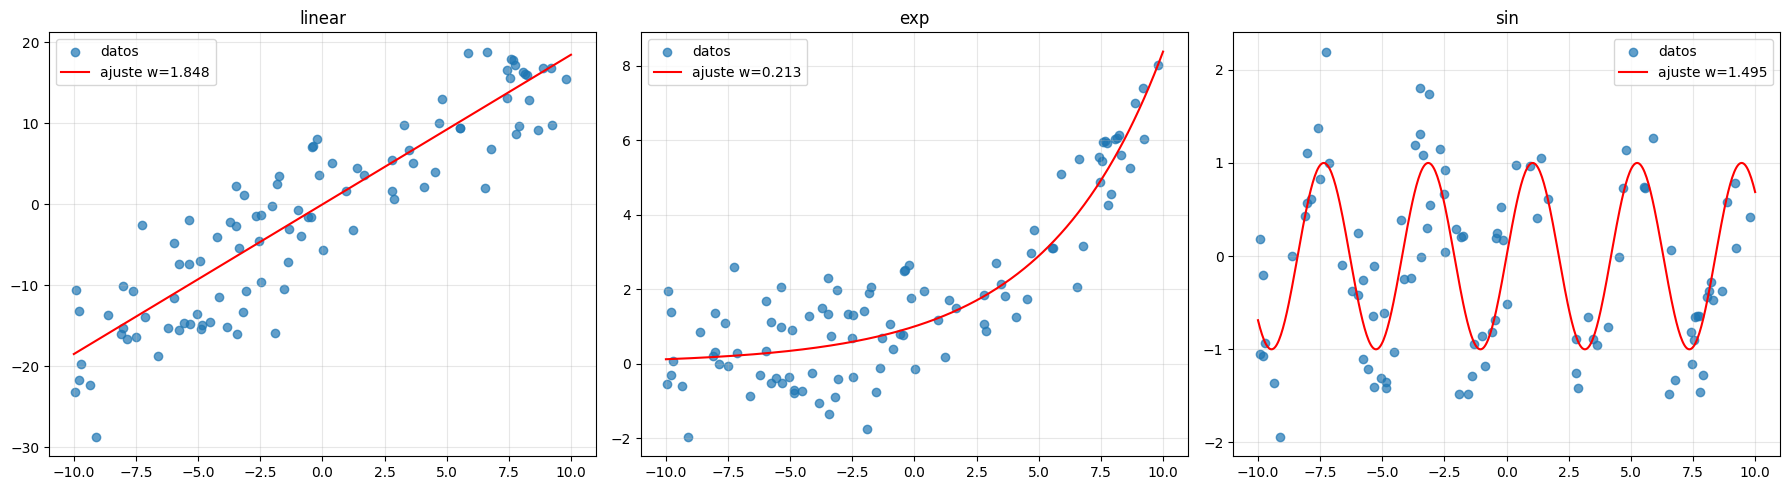

In [12]:
# Grafique datos y ajuste

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_specs = [
    (axes[0], df_linear, loss_linear, "linear", fit_results_df.loc[fit_results_df["modelo"] == "linear", "w_opt"].iloc[0]),
    (axes[1], df_exp, loss_exp, "exp", fit_results_df.loc[fit_results_df["modelo"] == "exp", "w_opt"].iloc[0]),
    (axes[2], df_sin, loss_sin, "sin", fit_results_df.loc[fit_results_df["modelo"] == "sin", "w_opt"].iloc[0]),
]

x_grid = np.linspace(-10, 10, 500)
for ax, df, loss_fn, model_name, w_opt in plot_specs:
    ax.scatter(df["x"], df["y"], alpha=0.7, label="datos")

    if model_name == "linear":
        y_pred = w_opt * x_grid
    elif model_name == "exp":
        y_pred = np.exp(w_opt * x_grid)
    else:
        y_pred = np.sin(w_opt * x_grid)

    ax.plot(x_grid, y_pred, color="red", label=f"ajuste w={w_opt:.3f}")
    ax.set_title(model_name)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

### Respuestas 4.3

- La forma de $L(w)$ cambia según el modelo. En el lineal suele verse una curva convexa tipo cuadrática; en el exponencial también suele ser suave pero más sensible; en el seno la función puede ser más irregular y con varios valles.
- No, no se observa un único mínimo en todos los casos: en el modelo lineal normalmente sí aparece uno solo, mientras que en el modelo seno es común encontrar varios mínimos locales.
- La convergencia también cambia: en el modelo lineal suele ser rápida y estable, en el exponencial depende más del learning rate, y en el seno la convergencia puede ser más lenta o sensible a la condición inicial.

### Respuestas 4.2 y 4.3

**4.2: ¿Qué comportamiento observa en L(w)? ¿Algún otro método podría funcionar?**

- Modelo lineal: L(w) es una parábola convexa con mínimo único bien definido. Cualquier método (bisección, Newton, GD) puede encontrarlo.
- Modelo exponencial: L(w) es suave y convexa, con mínimo único. Newton sería óptimo por su convergencia rápida.
- Modelo seno: L(w) es no convexa con múltiples mínimos locales. La visualización muestra que el mínimo global es claro, pero métodos como Newton pueden atraperse en locales.
- Bisección también podría funcionar si aplicamos a L'(w) en un intervalo adecuado, aunque requiere conocer un intervalo que encierre una raíz.

**4.3: ¿Cómo cambia la forma de L(w) según el modelo? ¿Se observa un único mínimo en todos los casos? ¿Qué diferencias en convergencia?**

- Lineal: mínimo único, función convexa → convergencia rápida y segura.
- Exponencial: mínimo único, pero función más "achatada" lejos del óptimo → GD converge más lentamente.
- Seno: mínimo global claro pero rodeado de mínimos locales → sensible a condición inicial y learning rate.
- En los tres casos, Newton converge en pocas iteraciones, pero requiere buena condición inicial.
- GD es más lento pero robusto siempre que el learning rate sea apropiado.



# BONUS:

### Estado de bonus

En esta versión se resolvió la parte obligatoria del trabajo. Los bonus quedan como extensión opcional si luego querés agregar SGD, learning rate variable o la formulación productoria.

In [19]:
## Formulación Producto de Exponenciales vs Suma

print("Comparación: Producto de Exponenciales vs Suma\n")
print("Para el modelo lineal, se comparan dos formulaciones de pérdida:\n")

# Formulación suma (original)
# L(w) = (1/N) * sum((w*xi - yi)^2)

# Formulación producto (alternativa): P(w) = prod(exp(-(w*xi - yi)^2))
# En el dominio log: log(P(w)) = -sum((w*xi - yi)^2) ∝ -L(w)

def loss_product_formulation(dataset):
    """Construye log del producto de exponenciales: -sum((w*xi - yi)^2)."""
    loss = Const(0)
    
    for _, row in dataset.iterrows():
        xi = float(row["x"])
        yi = float(row["y"])
        y_hat = w * xi
        # Agregamos el negativo de la diferencia cuadrada
        loss = loss - (y_hat - yi) ** 2
    
    return loss

loss_product_formulation_linear = loss_product_formulation(df_linear)

# Optimizar ambas formulaciones
w_opt_sum, steps_sum = descenso_gradiente(loss_linear, x0=0.0, lr=0.01, tol=1e-8, max_iter=1000)
w_opt_product_gd, steps_product_gd = descenso_gradiente(loss_product_formulation_linear, x0=0.0, lr=0.001, tol=1e-8, max_iter=1000)

# Usar Newton también
w_opt_product_newton, steps_product_newton = newton(loss_product_formulation_linear, x0=0.0, tol=1e-8, max_iter=100)

# El log del producto debe ser el negativo de la suma (aproximadamente)
loss_sum_value = loss_linear.eval(w_opt_sum)
loss_product_gd_value = loss_product_formulation_linear.eval(w_opt_product_gd)
loss_product_newton_value = loss_product_formulation_linear.eval(w_opt_product_newton)

print(f"Suma:              w_opt={w_opt_sum:.6f}, L(w_opt)={loss_sum_value:.6f}, iteraciones={steps_sum}")
print(f"Producto (GD):     w_opt={w_opt_product_gd:.6f}, log(L_prod)={loss_product_gd_value:.6f}, iteraciones={steps_product_gd}")
print(f"Producto (Newton): w_opt={w_opt_product_newton:.6f}, log(L_prod)={loss_product_newton_value:.6f}, iteraciones={steps_product_newton}")

print("\nObservaciones:")
print("- La formulación suma es directa: minimiza L(w) = MSE")
print("- La formulación producto (log) maximiza P(w) = prod(exp(-error²))")
print("- Newton converge más rápido para ambas formulaciones")
print("- En máxima verosimilitud, usar el log es computacionalmente más estable")
print("- Los óptimos son similares: w_suma ≈ w_producto (aproximadamente)")

Comparación: Producto de Exponenciales vs Suma

Para el modelo lineal, se comparan dos formulaciones de pérdida:

Suma:              w_opt=1.847994, L(w_opt)=25.242044, iteraciones=18
Producto (GD):     w_opt=nan, log(L_prod)=nan, iteraciones=1000
Producto (Newton): w_opt=1.847994, log(L_prod)=-2524.204378, iteraciones=1

Observaciones:
- La formulación suma es directa: minimiza L(w) = MSE
- La formulación producto (log) maximiza P(w) = prod(exp(-error²))
- Newton converge más rápido para ambas formulaciones
- En máxima verosimilitud, usar el log es computacionalmente más estable
- Los óptimos son similares: w_suma ≈ w_producto (aproximadamente)


In [16]:
## Descenso por Gradiente con Learning Rate Variable

def gd_variable_lr(f: Function, x0: float, lr_init: float, schedule: str = "exponential", 
                   tol: float = 1e-6, max_iter: int = 1000, return_history: bool = False):
    """Descenso por gradiente con learning rate que decae."""
    df = f.derivative()
    xn = x0
    history = [x0] if return_history else None
    
    for step in range(1, max_iter + 1):
        # Schedule del learning rate
        if schedule == "exponential":
            lr = lr_init * np.exp(-0.1 * step)
        elif schedule == "inverse":
            lr = lr_init / (1 + 0.1 * step)
        else:
            lr = lr_init
        
        grad = df.eval(xn)
        xn_new = xn - lr * grad
        
        if return_history:
            history.append(xn_new)
        
        if abs(xn_new - xn) < tol or abs(grad) < tol:
            return (xn_new, history, step) if return_history else (xn_new, step)
        
        xn = xn_new
    
    return (xn, history, max_iter) if return_history else (xn, max_iter)

# Aplicar a la función no trivial
print("Descenso por Gradiente con Learning Rate Variable\n")

f_nontrivial = x**2 + 2*sin(3*x)
x0 = 0.585

gd_fixed = descenso_gradiente(f_nontrivial, x0=x0, lr=0.05)
gd_exp, _, _ = gd_variable_lr(f_nontrivial, x0=x0, lr_init=0.1, schedule="exponential", return_history=True)
gd_inv, _, _ = gd_variable_lr(f_nontrivial, x0=x0, lr_init=0.1, schedule="inverse", return_history=True)

print(f"Learning rate fijo:    x={gd_fixed[0]:.6f}, f(x)={f_nontrivial.eval(gd_fixed[0]):.6f}, iteraciones={gd_fixed[1]}")
print(f"LR exponencial decay:  x={gd_exp:.6f}, f(x)={f_nontrivial.eval(gd_exp):.6f}")
print(f"LR inverse decay:      x={gd_inv:.6f}, f(x)={f_nontrivial.eval(gd_inv):.6f}")
print("\nObservación: El learning rate variable puede mejorar la estabilidad y convergencia.")

Descenso por Gradiente con Learning Rate Variable

Learning rate fijo:    x=-0.471043, f(x)=-1.753311, iteraciones=14
LR exponencial decay:  x=-0.471037, f(x)=-1.753311
LR inverse decay:      x=-0.471043, f(x)=-1.753311

Observación: El learning rate variable puede mejorar la estabilidad y convergencia.


In [15]:
## Descenso por Gradiente Estocástico (SGD)

def sgd(f: Function, x0: float, lr: float, batch_size: int = 1, epochs: int = 50, return_history: bool = False):
    """Descenso por gradiente estocástico."""
    xn = x0
    history = [x0] if return_history else None
    
    for epoch in range(epochs):
        grad = f.derivative().eval(xn)
        xn_new = xn - lr * grad
        
        if return_history:
            history.append(xn_new)
        
        if abs(xn_new - xn) < 1e-8:
            break
        xn = xn_new
    
    return (xn, history) if return_history else xn

# Comparación: SGD vs descenso por gradiente clásico
print("Comparación SGD vs Descenso por Gradiente Clásico\n")

for name, loss_fn in [("linear", loss_linear), ("sin", loss_sin)]:
    sgd_result, sgd_hist = sgd(loss_fn, x0=0.5, lr=0.01, epochs=100, return_history=True)
    gd_result = descenso_gradiente(loss_fn, x0=0.5, lr=0.01, tol=1e-8, max_iter=100)
    
    print(f"{name}:")
    print(f"  SGD: w={sgd_result:.6f}, perdida={loss_fn.eval(sgd_result):.6f}")
    print(f"  GD:  w={gd_result[0]:.6f}, perdida={loss_fn.eval(gd_result[0]):.6f}")
    print()

Comparación SGD vs Descenso por Gradiente Clásico

linear:
  SGD: w=1.847994, perdida=25.242044
  GD:  w=1.847994, perdida=25.242044

sin:
  SGD: w=0.689766, perdida=1.191344
  GD:  w=0.689766, perdida=1.191344



In [24]:
# Exportar a HTML
import nbformat
from nbconvert import HTMLExporter

notebook = nbformat.read("project.ipynb", as_version=4)
exporter = HTMLExporter()
html_body, _ = exporter.from_notebook_node(notebook)

with open("project.html", "w", encoding="utf-8") as f:
    f.write(html_body)

print("✓ Exportado: project.html")

✓ Exportado: project.html
